<a href="https://colab.research.google.com/github/rohaan2614/Federated_Learning/blob/master/GA_algo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Approximation

### Client Side

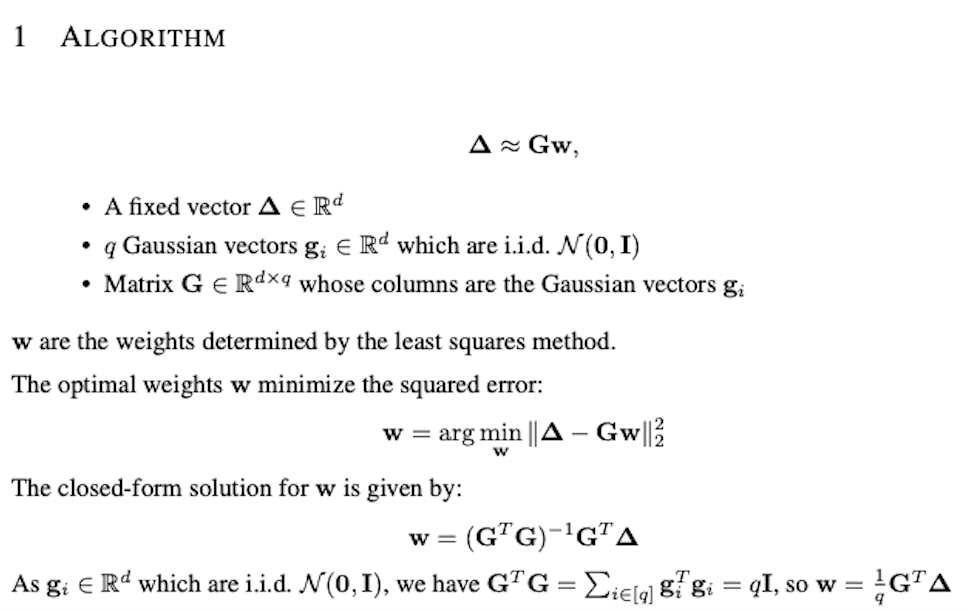

In [1]:
import numpy as np

def approximate_weights(seed, q, delta, trail = False):
  d = delta.shape[0]
  rng = np.random.default_rng(seed=seed)
  G = np.random.randn(d, q)
  if (trail) :
    print(f'-> d : {d}\n-> q : {q}\n-> G : \n{G}\n')
  return np.dot(G.transpose(), delta)/q

In [2]:
seed = 42
d = 3
q = 4
delta = np.random.randn(d)
print("-> Assume delta: \n", delta, "\n")

approximate_weights(seed = seed, q = q, delta = delta, trail = True)

-> Assume delta: 
 [-1.71539828 -1.09623167  0.13992887] 

-> d : 3
-> q : 4
-> G : 
[[ 1.58566955  1.25267113 -1.45714459 -0.95926519]
 [-0.21835875 -0.61961947  0.07258979 -0.34095013]
 [ 0.67271701  0.83367091  1.0503155  -1.02528306]]



array([-0.59663763, -0.3382322 ,  0.64174439,  0.46895387])

### Server Side Updates

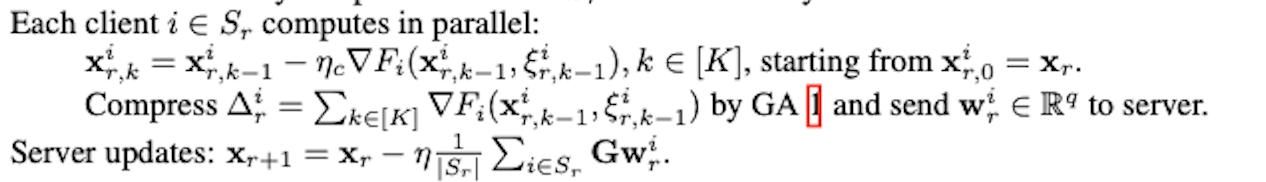

In [3]:
def update_model(old_model, lr, clients, seed, received_weights):
  new_model = old_model
  d = delta.shape[0]
  rng = np.random.default_rng(seed=seed)
  G = np.random.randn(d, q)
  sum = 0
  for received_weight in received_weights:
    sum += np.dot(G, received_weight)
    # print("sum: ", sum)
  return new_model - (sum * lr)/len(clients)

In [4]:
# Assume
x_r = np.random.randn(d)  # Current model parameters
lr = 0.01  # eta
Selected_clients = [0, 2]  # Indices of selected clients
w_r = [approximate_weights(seed, q, delta = np.random.randn(d)),
       approximate_weights(seed, q, delta = np.random.randn(d))]  # weights received from clients

print("Assume:")
print("Seed :", seed)
print("x_r :", x_r)
print("η :", lr)
print("Selected Clients :", Selected_clients)
print("Weights received from clients:")
for w in w_r:
  print(" -> ", w)

print("\n\n=> New Model: ", update_model(x_r, lr, Selected_clients, seed, w_r))

Assume:
Seed : 42
x_r : [-1.38035332 -1.21577537  1.84097043]
η : 0.01
Selected Clients : [0, 2]
Weights received from clients:
 ->  [-0.30561083 -0.41131754  0.85989565 -0.01116019]
 ->  [ 0.64757195  0.84330193 -0.06381751 -1.0792854 ]


=> New Model:  [-1.37945375 -1.21556911  1.84814111]
